<a href="https://colab.research.google.com/github/Vineesha2005/HPC-Project/blob/main/1873_HPC_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
from collections import Counter
import time
import re

# 🔹 Heavy processing to increase time
def heavy_processing(words):
    counter = Counter()
    for word in words:
        for _ in range(3):   # artificial load
            counter[word] += 1
    return counter

# Load dataset
df = pd.read_excel("log_dataset (1).xlsx")

text = " ".join(df.astype(str).values.flatten())
words = re.findall(r'\b\w+\b', text.lower())

# 🔥 Increase dataset size (important)
words = words * 50

start = time.time()
result = heavy_processing(words)
end = time.time()

print("Sequential Time:", end - start)
print("Top Words:", result.most_common(5))

Sequential Time: 13.493546485900879
Top Words: [('04', 7750200), ('06', 7750200), ('10', 7750200), ('2026', 7500000), ('to', 2223000)]


In [7]:
import pandas as pd
import multiprocessing
from collections import Counter
import time
import re

def count_words_chunk(words):
    return Counter(words)

def merge_counters(counters):
    total = Counter()
    for c in counters:
        total.update(c)
    return total

if __name__ == "__main__":

    df = pd.read_excel("log_dataset (1).xlsx")

    text = " ".join(df.astype(str).values.flatten())
    words = re.findall(r'\b\w+\b', text.lower())

    # 🔥 Same dataset size as serial
    words = words * 50

    num_cores = multiprocessing.cpu_count()

    chunk_size = len(words) // num_cores
    chunks = [words[i:i + chunk_size] for i in range(0, len(words), chunk_size)]

    start = time.time()

    with multiprocessing.Pool(processes=num_cores) as pool:
        results = pool.map(count_words_chunk, chunks)

    result = merge_counters(results)

    end = time.time()

    print("Parallel Time:", end - start)
    print("Top Words:", result.most_common(5))

Parallel Time: 4.502294063568115
Top Words: [('04', 2583400), ('06', 2583400), ('10', 2583400), ('2026', 2500000), ('to', 741000)]


Sequential Time: 13.550362825393677
Parallel Time: 4.120984315872192
Speedup: 3.2881374416310507


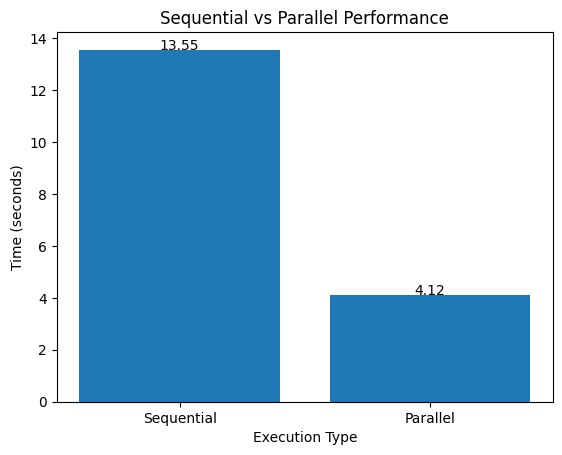

In [9]:
import pandas as pd
import multiprocessing
from collections import Counter
import time
import matplotlib.pyplot as plt
import re

def heavy_processing(words):
    counter = Counter()
    for word in words:
        for _ in range(3):
            counter[word] += 1
    return counter

def count_words_chunk(words):
    return Counter(words)

def merge_counters(counters):
    total = Counter()
    for c in counters:
        total.update(c)
    return total

if __name__ == "__main__":

    df = pd.read_excel("log_dataset (1).xlsx")
    text = " ".join(df.astype(str).values.flatten())
    words = re.findall(r'\b\w+\b', text.lower())

    # 🔥 Same dataset size
    words = words * 50

    # 🔸 SERIAL
    start = time.time()
    heavy_processing(words)
    serial_time = time.time() - start

    # 🔸 PARALLEL
    num_cores = multiprocessing.cpu_count()
    chunk_size = len(words) // num_cores
    chunks = [words[i:i + chunk_size] for i in range(0, len(words), chunk_size)]

    start = time.time()
    with multiprocessing.Pool(processes=num_cores) as pool:
        results = pool.map(count_words_chunk, chunks)

    merge_counters(results)
    parallel_time = time.time() - start

    print("Sequential Time:", serial_time)
    print("Parallel Time:", parallel_time)
    print("Speedup:", serial_time / parallel_time)

    # 🔸 GRAPH
    labels = ["Sequential", "Parallel"]
    times = [serial_time, parallel_time]

    plt.figure()
    plt.bar(labels, times)

    plt.title("Sequential vs Parallel Performance")
    plt.xlabel("Execution Type")
    plt.ylabel("Time (seconds)")

    for i in range(len(times)):
        plt.text(i, times[i], f"{times[i]:.2f}", ha='center')

    plt.savefig("comparison.png")
    plt.show()